In [57]:
"""
Copy-paste single-file script.

What this version adds vs your original:
1) Bulk WLS with *random absorption path length* (Beer–Lambert):
   - In any volume with wls=True and mu_a(λ)>0, we sample s_abs = -ln(U)/mu_a(λ)
   - If s_abs happens before the next boundary, we absorb there and (with QY) re-emit
2) Optional dichroic “mirror slab” behavior:
   - At interfaces into/out of the DM volume, apply wavelength-dependent reflect/transmit
   - Reflection is specular about the boundary normal; transmission continues forward
   - (You can switch this off by setting dm_is_dichroic=False)

Time-of-flight is intentionally omitted; compute later from the saved trajectory + n(λ).
"""

import numpy as np
import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import matplotlib.pyplot as plt


In [58]:
# ============================
# Optics helpers
# ============================

C0 = 299_792_458.0

def random_isotropic_direction(rng: np.random.Generator) -> np.ndarray:
    u = rng.uniform(-1.0, 1.0)
    phi = rng.uniform(0.0, 2.0*np.pi)
    s = np.sqrt(max(0.0, 1.0 - u*u))
    return np.array([s*np.cos(phi), s*np.sin(phi), u], dtype=float)

def reflect(direction: np.ndarray, normal: np.ndarray) -> np.ndarray:
    d = direction / np.linalg.norm(direction)
    n = normal / np.linalg.norm(normal)
    r = d - 2.0*np.dot(d, n)*n
    return r / np.linalg.norm(r)


def refract(direction, normal, n1, n2):
    cos_theta_i = -np.dot(normal, direction)
    sin2_theta_i = max(0.0, 1.0 - cos_theta_i**2)
    sin2_theta_t = (n1 / n2)**2 * sin2_theta_i

    if sin2_theta_t >= 1.0:
        return None  # Total internal reflection

    cos_theta_t = np.sqrt(1.0 - sin2_theta_t)
    return (n1 / n2) * direction + (cos_theta_i * (n1 / n2) - cos_theta_t) * normal

In [59]:
# -----------------------------
# Geometry: AABB cuboid
# -----------------------------

class Cuboid:
    """
    Axis-aligned cuboid. Optional physics:
      - wls: Beer–Lambert absorption in volume, with re-emission
      - mu_a: absorption coefficient [1/m] vs wavelength (dict/callable/scalar)
      - quantum_yield: re-emission probability after absorption
      - emission: either transitions dict (nearest key) or gaussian peak/sigma
      - is_dichroic: if True, apply reflectance/transmittance at interfaces
      - reflectance: dict/callable/scalar returning R(λ) in [0,1]
        (T is assumed 1-R; you can also set transmittance similarly if you want)
    """
    def __init__(
        self,
        vertices,
        refractive_index=None,
        name=None,
        wls=False,
        mu_a=0.0,
        quantum_yield=1.0,
        wls_transitions=None,
        emission_peak_nm=None,
        emission_sigma_nm=None,
        is_dichroic=False,
        reflectance=0.0,
    ):
        self.vertices = np.array(vertices, dtype=float)
        self.min_vertex = np.min(self.vertices, axis=0)
        self.max_vertex = np.max(self.vertices, axis=0)

        self.refractive_index = refractive_index if refractive_index is not None else {400.0: 1.0}
        self.name = name

        self.wls = bool(wls)
        self.mu_a = mu_a
        self.quantum_yield = float(quantum_yield)
        self.wls_transitions = wls_transitions or {}
        self.emission_peak_nm = emission_peak_nm
        self.emission_sigma_nm = emission_sigma_nm

        self.is_dichroic = bool(is_dichroic)
        self.reflectance = reflectance

    def contains(self, point, eps=1e-12):
        p = np.asarray(point, float)
        return np.all(p >= self.min_vertex - eps) and np.all(p <= self.max_vertex + eps)

    def intersect_distance(self, origin, direction):
        """
        Ray-AABB intersection distance to first hit (>=0). Returns inf if no hit.
        """
        o = np.asarray(origin, float)
        d = np.asarray(direction, float)

        inv = np.where(np.abs(d) > 0, 1.0 / d, np.inf)
        t0 = (self.min_vertex - o) * inv
        t1 = (self.max_vertex - o) * inv

        tmin = np.max(np.minimum(t0, t1))
        tmax = np.min(np.maximum(t0, t1))
        if tmax < 0 or tmin > tmax:
            return np.inf
        return tmin if tmin >= 0 else tmax

    def surface_normal_at(self, point, eps=1e-9):
        p = np.asarray(point, float)

        # Distances to each face plane
        dx_min = abs(p[0] - self.min_vertex[0])
        dx_max = abs(self.max_vertex[0] - p[0])
        dy_min = abs(p[1] - self.min_vertex[1])
        dy_max = abs(self.max_vertex[1] - p[1])
        dz_min = abs(p[2] - self.min_vertex[2])
        dz_max = abs(self.max_vertex[2] - p[2])

        dists = np.array([dx_min, dx_max, dy_min, dy_max, dz_min, dz_max])
        k = int(np.argmin(dists))

        # Return a pure axis normal
        if k == 0: return np.array([-1.0, 0.0, 0.0])
        if k == 1: return np.array([+1.0, 0.0, 0.0])
        if k == 2: return np.array([0.0, -1.0, 0.0])
        if k == 3: return np.array([0.0, +1.0, 0.0])
        if k == 4: return np.array([0.0, 0.0, -1.0])
        return np.array([0.0, 0.0, +1.0])

    def get_refractive_index(self, wavelength_nm):
        if isinstance(self.refractive_index, dict):
            keys = np.array(list(self.refractive_index.keys()), dtype=float)
            idx = int(np.abs(keys - wavelength_nm).argmin())
            return float(self.refractive_index[float(keys[idx])])
        if callable(self.refractive_index):
            return float(self.refractive_index(wavelength_nm))
        return float(self.refractive_index)

    def get_mu_a(self, wavelength_nm):
        if isinstance(self.mu_a, dict):
            keys = np.array(list(self.mu_a.keys()), dtype=float)
            idx = int(np.abs(keys - wavelength_nm).argmin())
            return float(self.mu_a[float(keys[idx])])
        if callable(self.mu_a):
            return float(self.mu_a(wavelength_nm))
        return float(self.mu_a)

    def get_reflectance(self, wavelength_nm):
        if isinstance(self.reflectance, dict):
            keys = np.array(list(self.reflectance.keys()), dtype=float)
            idx = int(np.abs(keys - wavelength_nm).argmin())
            return float(self.reflectance[float(keys[idx])])
        if callable(self.reflectance):
            return float(self.reflectance(wavelength_nm))
        return float(self.reflectance)

    def sample_emission_wavelength(self, rng, in_lambda_nm):
        # 1) transitions dict (nearest key)
        if self.wls_transitions:
            keys = np.array(list(self.wls_transitions.keys()), dtype=float)
            idx = int(np.abs(keys - in_lambda_nm).argmin())
            return float(self.wls_transitions[float(keys[idx])])
        # 2) gaussian peak/sigma
        if self.emission_peak_nm is not None:
            sigma = float(self.emission_sigma_nm) if self.emission_sigma_nm is not None else 10.0
            out = rng.normal(loc=float(self.emission_peak_nm), scale=sigma)
            return float(max(1.0, out))
        # 3) no shift
        return float(in_lambda_nm)

    def which_face(self, point, eps=1e-9):
        p = np.asarray(point, float)
        if abs(p[0] - self.min_vertex[0]) < eps: return "xmin"
        if abs(p[0] - self.max_vertex[0]) < eps: return "xmax"
        if abs(p[1] - self.min_vertex[1]) < eps: return "ymin"
        if abs(p[1] - self.max_vertex[1]) < eps: return "ymax"
        if abs(p[2] - self.min_vertex[2]) < eps: return "zmin"
        if abs(p[2] - self.max_vertex[2]) < eps: return "zmax"
        return None

In [60]:
# =========================================================
# PhotonSimulation (COMPLETE, latest logic)
# =========================================================

class PhotonSimulation:
    def __init__(
        self,
        volumes=None,
        source_position=None,
        sensor_positions=None,
        sensor_radius=0,
        num_photons=1000,
        max_thrown=10000,
        max_workers=8,
        initial_wavelength=400
    ):
        self.volumes = []
        if volumes is not None:
            for v in volumes:
                self.volumes.append(
                    Cuboid(
                        v['vertices'],
                        refractive_index=v.get('refractive_index', {initial_wavelength: 1.0}),
                        name=v.get('name'),
                        wls=v.get('wls', False),
                        wls_transitions=v.get('wls_transitions', {}),
                        wls_prob=v.get('wls_prob', 0.0)
                    )
                )
        self.source_position = np.array(source_position) if source_position is not None else None
        self.sensor_positions = np.array(sensor_positions) if sensor_positions is not None else None
        self.sensor_radius = sensor_radius
        self.num_photons = num_photons
        self.max_thrown = max_thrown
        self.c = 3e8  # Speed of light in vacuum (m/s)
        self.positions_history = []
        self.max_workers = max_workers
        self.initial_wavelength = initial_wavelength

        if self.volumes:
            all_vertices = np.vstack([v.vertices for v in self.volumes])
            self.combined_region = Cuboid(all_vertices)
        else:
            self.combined_region = None

        self.data = []

    def find_containing_volume(self, point):
        for idx, v in enumerate(self.volumes):
            if v.contains(point):
                return idx, v
        return None, None

    def propagate_single_photon(self):
        phi = np.random.uniform(0, 2 * np.pi)
        theta = np.random.uniform(0, np.pi)

        direction = np.array([np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)])
        position = np.copy(self.source_position)
        time = 0
        trajectory = [position.tolist()]
        reflections = 0
        path_length = 0
        wavelength = self.initial_wavelength
        wavelength_history = [wavelength]

        idx, current_volume = self.find_containing_volume(position)
        if current_volume is None:
            return trajectory, time, 'lost', reflections, phi, theta, path_length, wavelength_history

        while True:
            if not self.combined_region.contains(position):
                return trajectory, time, f'lost_{current_volume.name or idx}', reflections, phi, theta, path_length, wavelength_history

            t = current_volume.intersect(position, direction)
            if t == np.inf:
                return trajectory, time, f'lost_{current_volume.name or idx}', reflections, phi, theta, path_length, wavelength_history

            new_position = position + direction * t
            trajectory.append(new_position.tolist())
            path_length += np.linalg.norm(new_position - position)
            n_current = current_volume.get_refractive_index(wavelength)
            time += t / (self.c / n_current)

            if np.any([np.linalg.norm(new_position - sensor_position) <= self.sensor_radius for sensor_position in self.sensor_positions]):
                path_length += np.linalg.norm(new_position - position)
                trajectory.append(new_position.tolist())
                return trajectory, time, 'arrived', reflections, phi, theta, path_length, wavelength_history

            # Check if photon enters a new volume
            next_idx, next_volume = self.find_containing_volume(new_position)
            if next_idx is not None and next_idx != idx:
                # Wavelength shifting possibility
                if current_volume.wls and wavelength in current_volume.wls_transitions:
                    if np.random.rand() < current_volume.wls_prob:
                        wavelength = current_volume.wls_transitions[wavelength]
                wavelength_history.append(wavelength)

                # Crossing interface
                normal = np.sign(new_position - np.where(new_position < (current_volume.min_vertex + current_volume.max_vertex) / 2, current_volume.min_vertex, current_volume.max_vertex))
                n1 = current_volume.get_refractive_index(wavelength)
                n2 = next_volume.get_refractive_index(wavelength)
                critical_angle = None
                if n2 < n1:
                    critical_angle = np.arcsin(n2 / n1)
                incidence_angle = np.arccos(np.abs(np.dot(direction, normal)) / (np.linalg.norm(direction) * np.linalg.norm(normal)))
                refracted_direction = refract(direction, normal, n1, n2)
                if refracted_direction is not None:
                    direction = refracted_direction
                    idx = next_idx
                    current_volume = next_volume
                else:
                    # Total internal reflection
                    direction -= 2 * np.dot(direction, normal) * normal
                    reflections += 1
            elif next_idx is None:
                # Exiting all volumes
                return trajectory, time, f'lost_{current_volume.name or idx}', reflections, phi, theta, path_length, wavelength_history
            else:
                # Reflection at boundary
                position = new_position
                normal = np.sign(new_position - np.where(new_position < (current_volume.min_vertex + current_volume.max_vertex) / 2, current_volume.min_vertex, current_volume.max_vertex))
                direction -= 2 * np.dot(direction, normal) * normal
                reflections += 1
                position = new_position

        return trajectory, time, 'lost', reflections, phi, theta, path_length, wavelength_history

    def propagate_photons(self):
        start_time = time.time()

        successful_photons = 0
        total_photons_thrown = 0
        successful_times = []

        with ThreadPoolExecutor(max_workers=self.max_workers) as executor:
            futures = {executor.submit(self.propagate_single_photon): i for i in range(self.max_thrown)}
            with tqdm(total=self.max_thrown, desc='Overall Progress', position=0, leave=True) as overall_progress:
                for future in as_completed(futures):
                    total_photons_thrown += 1
                    trajectory, time_taken, status, reflections, phi, theta, path_length, wavelength_history = future.result()
                    overall_progress.update(1)
                    self.data.append({
                        'trajectory': self.serialize_trajectory(trajectory),
                        'reflections': reflections,
                        'phi': phi,
                        'theta': theta,
                        'lost': status != 'arrived',
                        'arrived': status == 'arrived',
                        'time_of_flight': time_taken,
                        'path_length': path_length,
                        'n_reflections': reflections,
                        'event_type': status,
                        'wavelength_history': ";".join(map(str, wavelength_history))
                    })
                    if status == 'arrived':
                        successful_times.append(time_taken)
                        successful_photons += 1
                        if successful_photons >= self.num_photons:
                            break

                    if total_photons_thrown >= self.max_thrown:
                        break

        end_time = time.time()

        total_time = end_time - start_time
        mean_time_per_photon = total_time / total_photons_thrown
        mean_time_per_arrived_photon = total_time / successful_photons if successful_photons > 0 else 0

        self.total_photons_thrown = total_photons_thrown
        self.successful_times = successful_times
        self.total_time = total_time
        self.mean_time_per_photon = mean_time_per_photon
        self.mean_time_per_arrived_photon = mean_time_per_arrived_photon
        self.data_df = pd.DataFrame(self.data)

        print(f'Total photons thrown: {self.total_photons_thrown}')
        print(f'Number of successful photons: {len(self.data_df[self.data_df["event_type"] == "arrived"])}')
        for v in self.volumes:
            name = v.name or self.volumes.index(v)
            lost_count = len(self.data_df[self.data_df["event_type"] == f"lost_{name}"])
            print(f'Number of lost photons in {name}: {lost_count}')

    def serialize_trajectory(self, trajectory):
        return ";".join([",".join(map(str, point)) for point in trajectory])

    def deserialize_trajectory(self, trajectory_str):
        if isinstance(trajectory_str, list):  # Already deserialized
            return trajectory_str
        return [list(map(float, point.split(','))) for point in trajectory_str.split(';')]

    def visualize_setup(self, show=['arrived']):
        fig = go.Figure()

        def draw_cuboid(fig, vertices, color='gray'):
            edges = [
                [0, 1], [1, 2], [2, 3], [3, 0],
                [4, 5], [5, 6], [6, 7], [7, 4],
                [0, 4], [1, 5], [2, 6], [3, 7]
            ]

            for edge in edges:
                fig.add_trace(go.Scatter3d(
                    x=[vertices[edge[0]][0], vertices[edge[1]][0]],
                    y=[vertices[edge[0]][1], vertices[edge[1]][1]],
                    z=[vertices[edge[0]][2], vertices[edge[1]][2]],
                    mode='lines', line=dict(color=color)
                ))

        def draw_sensors(fig, sensor_positions, sensor_radius):
            for sensor_position in sensor_positions:
                u = np.linspace(0, 2 * np.pi, 100)
                v = np.linspace(0, np.pi, 100)
                x = sensor_radius * np.outer(np.cos(u), np.sin(v)) + sensor_position[0]
                y = sensor_radius * np.outer(np.sin(u), np.sin(v)) + sensor_position[1]
                z = sensor_radius * np.outer(np.ones(np.size(u)), np.cos(v)) + sensor_position[2]
                fig.add_trace(go.Surface(x=x, y=y, z=z, opacity=0.5, colorscale='Reds', showscale=False))

        def draw_light_source(fig, source_position):
            fig.add_trace(go.Scatter3d(x=[source_position[0]], y=[source_position[1]], z=[source_position[2]], mode='markers', marker=dict(color='blue', size=5), name='Light Source'))

        def draw_trajectories(fig, trajectories, color):
            for trajectory in trajectories:
                if len(trajectory) == 0:
                    continue
                trajectory = np.array(trajectory)
                if trajectory.ndim != 2 or trajectory.shape[1] != 3:
                    continue
                fig.add_trace(go.Scatter3d(
                    x=trajectory[:, 0], y=trajectory[:, 1], z=trajectory[:, 2],
                    mode='lines', line=dict(color=color)
                ))

        # Draw all volumes
        colors = ['gray', 'purple', 'cyan', 'yellow', 'magenta', 'orange', 'brown', 'pink']
        for i, v in enumerate(self.volumes):
            draw_cuboid(fig, v.vertices, color=colors[i % len(colors)])

        if self.sensor_positions is not None:
            draw_sensors(fig, self.sensor_positions, self.sensor_radius)
        if self.source_position is not None:
            draw_light_source(fig, self.source_position)

        if 'arrived' in show:
            arrived_trajectories = [self.deserialize_trajectory(d['trajectory']) for d in self.data if d['event_type'] == 'arrived']
            draw_trajectories(fig, arrived_trajectories, 'green')
        for v in self.volumes:
            name = v.name or self.volumes.index(v)
            key = f'lost_{name}'
            if key in show:
                lost_trajectories = [self.deserialize_trajectory(d['trajectory']) for d in self.data if d['event_type'] == key]
                draw_trajectories(fig, lost_trajectories, colors[self.volumes.index(v) % len(colors)])

        fig.update_layout(scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ), title=f'Volumes with Light Source, Sensors, and Photon Trajectories ({", ".join(show)})')

        fig.show()

    def save_config(self, filename=None):
        config = {
            'volumes': [
                {
                    'vertices': v.vertices.tolist(),
                    'refractive_index': v.refractive_index if not callable(v.refractive_index) else None,
                    'name': v.name,
                    'wls': v.wls,
                    'wls_transitions': v.wls_transitions,
                    'wls_prob': v.wls_prob
                } for v in self.volumes
            ],
            'source_position': self.source_position.tolist(),
            'sensor_positions': self.sensor_positions.tolist(),
            'sensor_radius': self.sensor_radius,
            'num_photons': self.num_photons,
            'max_thrown': self.max_thrown,
            'max_workers': self.max_workers,
            'initial_wavelength': self.initial_wavelength
        }
        if filename is None:
            filename = f"config_{self.num_photons}_photons_{datetime.now().strftime('%Y%m%d')}.json"
        with open(filename, 'w') as f:
            json.dump(config, f, indent=4)

    def save_results(self, filename=None):
        if filename is None:
            filename = f"results_{self.num_photons}_photons_{datetime.now().strftime('%Y%m%d')}.csv"
        self.data_df.to_csv(filename, index=False)

    def load_config(self, filename):
        with open(filename, 'r') as f:
            config = json.load(f)
        self.volumes = []
        for v in config['volumes']:
            self.volumes.append(Cuboid(
                v['vertices'],
                refractive_index=v.get('refractive_index', {config.get('initial_wavelength', 400): 1.0}),
                name=v.get('name'),
                wls=v.get('wls', False),
                wls_transitions=v.get('wls_transitions', {}),
                wls_prob=v.get('wls_prob', 0.0)
            ))
        self.source_position = np.array(config['source_position'])
        self.sensor_positions = np.array(config['sensor_positions'])
        self.sensor_radius = config['sensor_radius']
        self.num_photons = config['num_photons']
        self.max_thrown = config['max_thrown']
        self.max_workers = config['max_workers']
        self.initial_wavelength = config.get('initial_wavelength', 400)

        all_vertices = np.vstack([v.vertices for v in self.volumes])
        self.combined_region = Cuboid(all_vertices)

    def load_results(self, filename):
        self.data_df = pd.read_csv(filename)
        self.data_df['trajectory'] = self.data_df['trajectory'].apply(self.deserialize_trajectory)
        self.data = self.data_df.to_dict('records')


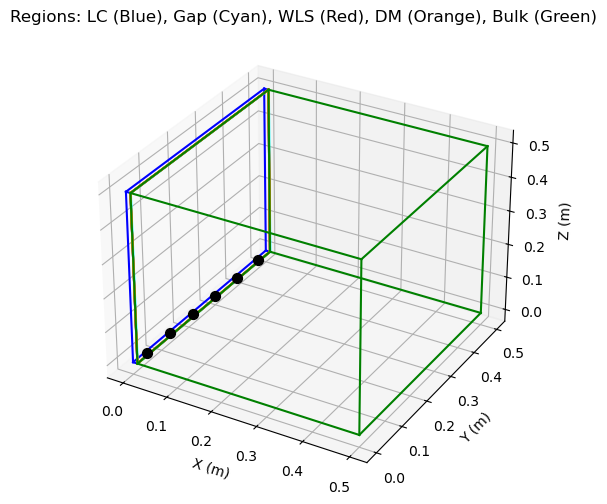

In [61]:
# =========================================================
# YOUR SETUP (directly integrated)
# =========================================================

# define config inputs
width = 0.5  # meters
height = 0.5  # meters
# bulk
bulk_x = 0.5
bulk_y = height
bulk_z = width
# wls
wls_x = 3e-6
wls_y = height
wls_z = width
# dichroic mirror
dm_x = 112e-6
dm_y = height
dm_z = width
# gap
lar_gap_x = 1e-3
lar_gap_y = height
lar_gap_z = width
# lc
lc_x = 1e-2
lc_y = height
lc_z = width

# sensors
n_sipms = 6
sensor_positions = [[lc_x/2.0, (1 + 2 * i) / (2 * n_sipms) * height, 0.0] for i in range(n_sipms)]

# Light collection region (LC)
lc_region_vertices = [
    [0, 0, 0], [lc_x, 0, 0],
    [lc_x, lc_y, 0], [0, lc_y, 0],
    [0, 0, lc_z], [lc_x, 0, lc_z],
    [lc_x, lc_y, lc_z], [0, lc_y, lc_z]
]

# liquid argon gap between LC and WLS
lar_gap_vertices = [
    [lc_x, 0, 0], [lc_x + lar_gap_x, 0, 0],
    [lc_x + lar_gap_x, lar_gap_y, 0], [lc_x, lar_gap_y, 0],
    [lc_x, 0, lar_gap_z], [lc_x + lar_gap_x, 0, lar_gap_z],
    [lc_x + lar_gap_x, lar_gap_y, lar_gap_z], [lc_x, lar_gap_y, lar_gap_z]
]

# Wavelength shifter region (WLS), sits after LC along x-axis
wls_region_vertices = [
    [lc_x, 0, 0], [lc_x + wls_x, 0, 0],
    [lc_x + wls_x, wls_y, 0], [lc_x, wls_y, 0],
    [lc_x, 0, wls_z], [lc_x + wls_x, 0, wls_z],
    [lc_x + wls_x, wls_y, wls_z], [lc_x, wls_y, wls_z]
]

# Dichroic mirror region (DM), sits after WLS along x-axis
dm_region_vertices = [
    [lc_x + wls_x, 0, 0], [lc_x + wls_x + dm_x, 0, 0],
    [lc_x + wls_x + dm_x, dm_y, 0], [lc_x + wls_x, dm_y, 0],
    [lc_x + wls_x, 0, dm_z], [lc_x + wls_x + dm_x, 0, dm_z],
    [lc_x + wls_x + dm_x, dm_y, dm_z], [lc_x + wls_x, dm_y, dm_z]
]

# Bulk region, sits after DM along x-axis
bulk_region_vertices = [
    [lc_x + wls_x + dm_x, 0, 0], [bulk_x, 0, 0],
    [bulk_x, bulk_y, 0], [lc_x + wls_x + dm_x, bulk_y, 0],
    [lc_x + wls_x + dm_x, 0, bulk_z], [bulk_x, 0, bulk_z],
    [bulk_x, bulk_y, bulk_z], [lc_x + wls_x + dm_x, bulk_y, bulk_z]
]

# Visualisation of the regions
plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

def draw_box(vertices, color):
    V = np.array(vertices, dtype=float)
    edges = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]
    for a,b in edges:
        ax.plot([V[a,0],V[b,0]],[V[a,1],V[b,1]],[V[a,2],V[b,2]], color=color)

draw_box(lc_region_vertices, "blue")
draw_box(lar_gap_vertices, "cyan")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
    ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title("Regions: LC (Blue), Gap (Cyan), WLS (Red), DM (Orange), Bulk (Green)")
plt.show()

In [62]:
# =========================================================
# Physics knobs (EDIT THESE!)
# =========================================================

# --- EJ280 (LC) absorption coefficient mu_a [1/m] vs wavelength.
# You *must* tune these. If you set mu_a too small, almost no absorption->reemission.
# If too big, everything shifts immediately.
mu_a_lc = {
    128.0: 0.0,     # EJ280 typically not absorbing VUV if it doesn't see it; set as you like
    420.0: 20.0,    # example: absorption length 5 cm
    490.0: 0.2,     # example: mostly transparent at its own emission
}

# EJ280 emission ~490 nm (example)
lc_qy = 0.95

# --- TPB (WLS slab) absorption coefficient mu_a [1/m] vs wavelength.
# For a 3 µm film, mu_a can be enormous in VUV; treat these as placeholders.
mu_a_tpb = {
    128.0: 5e5,     # example: absorption length 2 microns
    420.0: 10.0,    # TPB mostly transparent in blue
    490.0: 1.0,
}
tpb_qy = 0.9

# --- Dichroic: reflectance vs wavelength (placeholders).
# For example: reflect blue (420) strongly, transmit green (490) mostly.
# You can invert this depending on your design.
dm_is_dichroic = True
dm_reflectance = {
    128.0: 0.2,
    420.0: 0.95,
    490.0: 0.10,
}

In [63]:
# =========================================================
# Define volumes (as Cuboid objects)
# =========================================================

lc = Cuboid(
    vertices=lc_region_vertices,
    refractive_index={128: 1.65, 420: 1.60, 490: 1.58},
    name="lc",
    wls=True,                          # EJ280 as bulk WLS
    mu_a=mu_a_lc,
    quantum_yield=lc_qy,
    emission_peak_nm=490.0,
    emission_sigma_nm=20.0,
)
lc.boundary_mode = {
    "ymin": "reflect",
    "ymax": "reflect",
    "zmin": "reflect",
    "zmax": "reflect",
    "xmin": "reflect",   # sensor side maybe?
    "xmax": "escape",
}
lc.reflectivity = {
    "ymin": 0.98,
    "ymax": 0.98,
    "zmin": 0.98,
    "zmax": 0.98,
    "xmin": 0.98,
}

lar_gap = Cuboid(
    vertices=lar_gap_vertices,
    refractive_index={128: 1.6, 420: 1.23, 490: 1.22},
    name="lar_gap",
    wls=False,
)
lar_gap.boundary_mode = {
    "ymin": "escape",
    "ymax": "escape",
    "zmin": "escape",
    "zmax": "escape",
    "xmin": "escape",   # sensor side maybe?
    "xmax": "escape",
}

wls = Cuboid(
    vertices=wls_region_vertices,
    refractive_index={128: 1.70, 420: 1.62, 490: 1.60},
    name="wls",
    wls=True,                          # TPB slab as bulk WLS
    mu_a=mu_a_tpb,
    quantum_yield=tpb_qy,
    emission_peak_nm=420.0,
    emission_sigma_nm=15.0,
)
wls.boundary_mode = {
    "ymin": "escape",
    "ymax": "escape",
    "zmin": "escape",
    "zmax": "escape",
    "xmin": "escape",   # sensor side maybe?
    "xmax": "escape",
}

dm = Cuboid(
    vertices=dm_region_vertices,
    refractive_index={128: 1.5, 420: 1.65, 490: 1.9},
    name="dm",
    wls=False,
    is_dichroic=dm_is_dichroic,
    reflectance=dm_reflectance,
)
dm.boundary_mode = {
    "ymin": "escape",
    "ymax": "escape",
    "zmin": "escape",
    "zmax": "escape",
    "xmin": "escape",   # sensor side maybe?
    "xmax": "escape",
}

bulk = Cuboid(
    vertices=bulk_region_vertices,
    refractive_index={128: 1.6, 420: 1.23, 490: 1.22},
    name="bulk",
    wls=False,
)
bulk.boundary_mode = {
    "ymin": "escape",
    "ymax": "escape",
    "zmin": "escape",
    "zmax": "escape",
    "xmin": "escape",   # sensor side maybe?
    "xmax": "escape",
}

volumes = [lc, lar_gap, wls, dm, bulk]

In [64]:
# =========================================================
# Run simulation
# =========================================================

simulation = PhotonSimulation(
    volumes=volumes,
    source_position=[0.25, 0.25, 0.25],
    sensor_positions=sensor_positions,
    sensor_radius=0.01,
    num_photons=10000,
    max_thrown=100000,
    max_workers=8,
    initial_wavelength=128.0,   # LAr scintillation example
)

simulation.propagate_photons()

# DataFrame available as:
df = simulation.data_df
print(df.head())

TypeError: 'Cuboid' object is not subscriptable

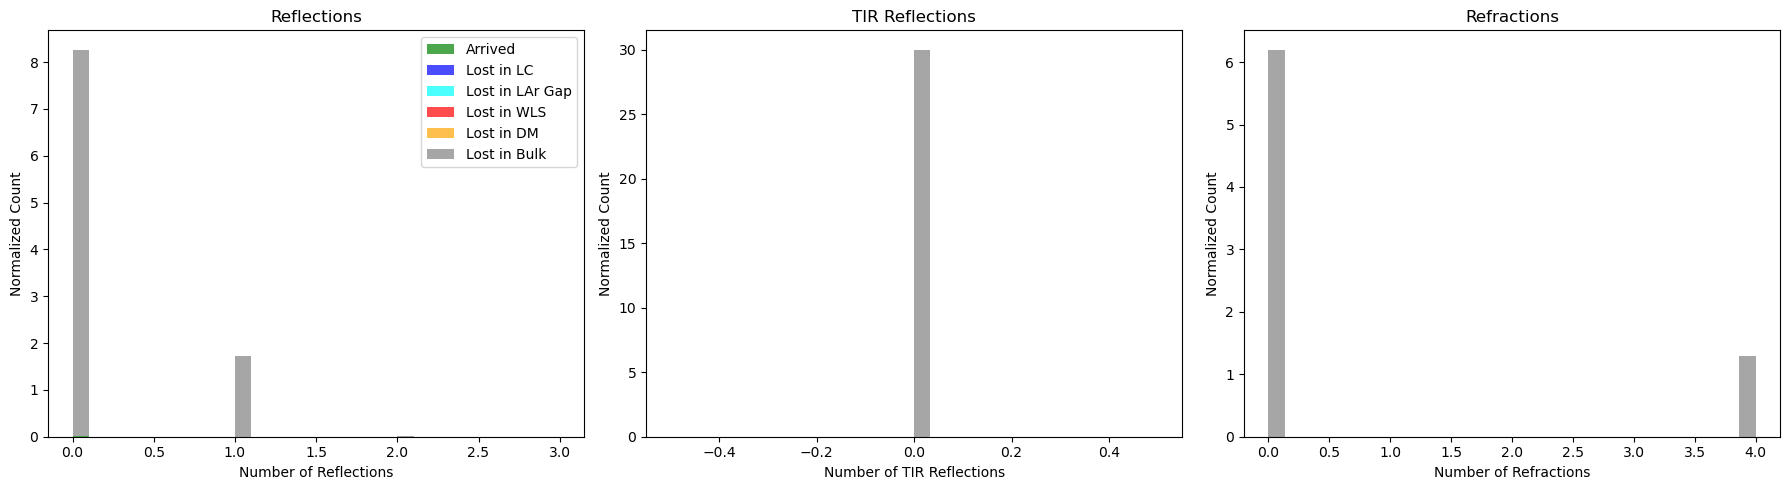

In [ ]:
# plot stacked histogram of n_reflections, n_tir_reflections, n_refractions for all photons
plt.figure(figsize=(18, 5))

event_types = ['arrived', 'lost_lc', 'lost_lar_gap', 'lost_wls', 'lost_dm', 'lost_bulk']
colors = ['green', 'blue', 'cyan', 'red', 'orange', 'gray']
labels = ['Arrived', 'Lost in LC', 'Lost in LAr Gap', 'Lost in WLS', 'Lost in DM', 'Lost in Bulk']

# 1. Reflections
plt.subplot(1, 3, 1)
plt.hist(
  [df[df['event_type'] == et]['n_reflections'] for et in event_types],
  bins=30,
  stacked=True,
  color=colors,
  label=labels,
  alpha=0.7,
  density=True
)
plt.xlabel("Number of Reflections")
plt.ylabel("Normalized Count")
plt.title("Reflections")
plt.legend()

# 2. TIR Reflections
plt.subplot(1, 3, 2)
plt.hist(
  [df[df['event_type'] == et]['n_tir'] for et in event_types],
  bins=30,
  stacked=True,
  color=colors,
  label=labels,
  alpha=0.7,
  density=True
)
plt.xlabel("Number of TIR Reflections")
plt.ylabel("Normalized Count")
plt.title("TIR Reflections")

# 3. Refractions
plt.subplot(1, 3, 3)
plt.hist(
  [df[df['event_type'] == et]['n_refractions'] for et in event_types],
  bins=30,
  stacked=True,
  color=colors,
  label=labels,
  alpha=0.7,
  density=True
)
plt.xlabel("Number of Refractions")
plt.ylabel("Normalized Count")
plt.title("Refractions")

plt.tight_layout()
plt.show()

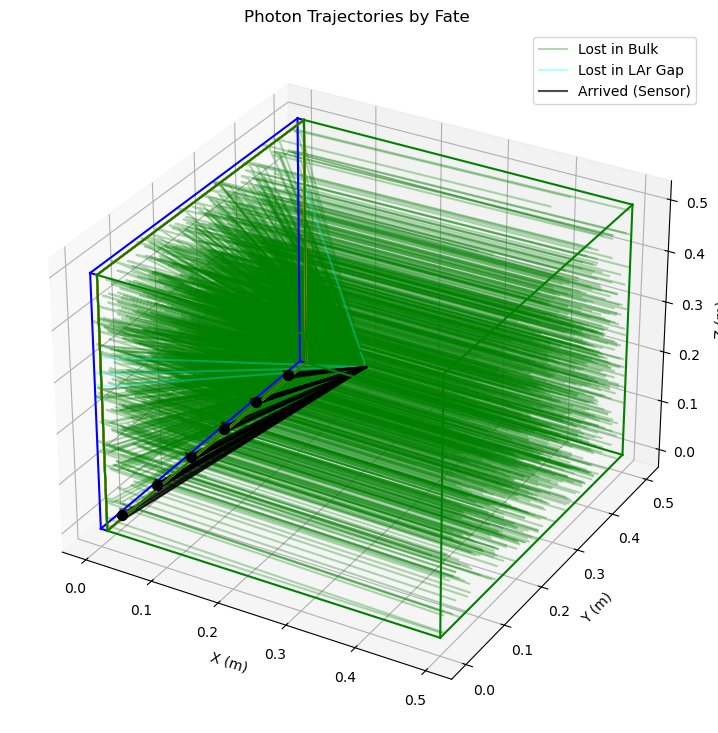

In [ ]:
# Plot trajectories by event type: lost_bulk, lost_dm, lost_wls, lost_lc, arrived

plt.figure(figsize=(12, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

# Helper for plotting
def plot_trajectories(df_subset, color, label, alpha=0.3, max_lines=1000):
    for i, traj_str in enumerate(df_subset['trajectory']):
        if i >= max_lines:
            break
        points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
        ax.plot(points[:,0], points[:,1], points[:,2], color=color, alpha=alpha, label=label if i == 0 else None)

# Plot each event type
#plot_trajectories(df[df['event_type'] == 'lost_bulk'], 'green', 'Lost in Bulk')
# plot only lost in bulk with at least one reflection
plot_trajectories(df[(df['event_type'] == 'lost_bulk') & (df['n_refractions'] > 0)], 'green', 'Lost in Bulk')
plot_trajectories(df[df['event_type'] == 'lost_dm'], 'orange', 'Lost in DM')
plot_trajectories(df[df['event_type'] == 'lost_wls'], 'red', 'Lost in WLS')
plot_trajectories(df[df['event_type'] == 'lost_lar_gap'], 'cyan', 'Lost in LAr Gap')
plot_trajectories(df[df['event_type'] == 'lost_lc'], 'blue', 'Lost in LC')
plot_trajectories(df[df['event_type'] == 'arrived'], 'k', 'Arrived (Sensor)', alpha=0.7)

# Draw geometry
draw_box(lc_region_vertices, "blue")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
    ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title('Photon Trajectories by Fate')
ax.legend()
plt.show()

In [ ]:
import plotly.graph_objects as go

# Filter only arrived photons
df_arrived = df[df['event_type'] == 'arrived']

fig = go.Figure()

# Plot up to 500 trajectories for clarity
for i, traj_str in enumerate(df_arrived['trajectory']):
  if i >= 500:
    break
  points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
  fig.add_trace(go.Scatter3d(
    x=points[:,0], y=points[:,1], z=points[:,2],
    mode='lines',
    line=dict(color='black', width=2),
    opacity=0.5,
    name='Photon' if i == 0 else None,
    showlegend=(i == 0)
  ))

# Add sensor positions
sensor_pos = np.array(sensor_positions)
fig.add_trace(go.Scatter3d(
  x=sensor_pos[:,0], y=sensor_pos[:,1], z=sensor_pos[:,2],
  mode='markers',
  marker=dict(size=6, color='red'),
  name='Sensors'
))

fig.update_layout(
  scene=dict(
    xaxis_title='X (m)',
    yaxis_title='Y (m)',
    zaxis_title='Z (m)',
  ),
  title='Arrived Photon Trajectories (Interactive)',
  legend=dict(itemsizing='constant')
)

fig.show()

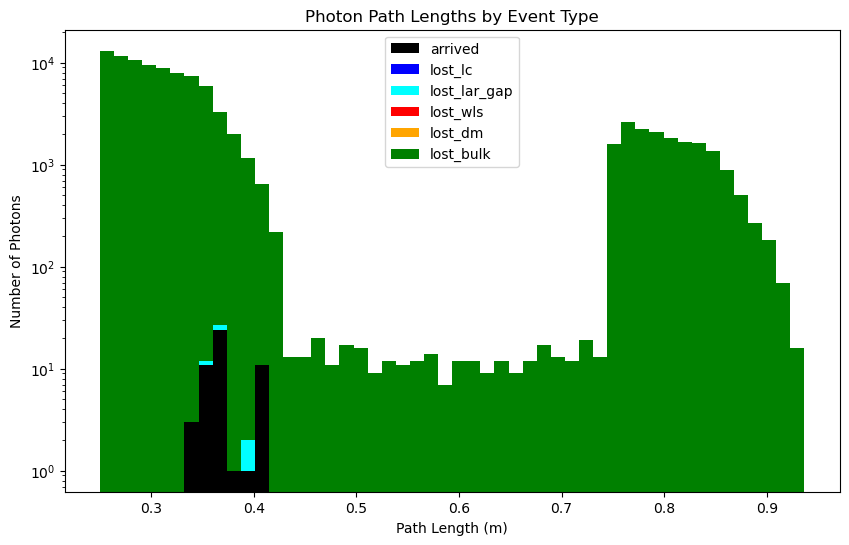

Overall detection efficiency: 0.51% (51 / 10000)


In [ ]:
# stacked histgram of pathlengths by event type
plt.figure(figsize=(10, 6))
event_types = ['arrived', 'lost_lc', 'lost_lar_gap', 'lost_wls', 'lost_dm', 'lost_bulk']
colors = ['k', 'blue', 'cyan', 'red', 'orange', 'green']
plt.hist(
    [simulation.data_df[simulation.data_df['event_type'] == et]['path_length'] for et in event_types],
    bins=50,
    stacked=True,
    color=colors,
    label=event_types,
)
plt.xlabel('Path Length (m)')
plt.ylabel('Number of Photons')
plt.yscale('log')
plt.title('Photon Path Lengths by Event Type')
plt.legend()
plt.show()

# print efficiency
n_arrived = int(simulation.data_df['arrived'].sum())
efficiency = n_arrived / simulation.num_photons * 100.0
print(f"Overall detection efficiency: {efficiency:.2f}% ({n_arrived} / {simulation.num_photons})")

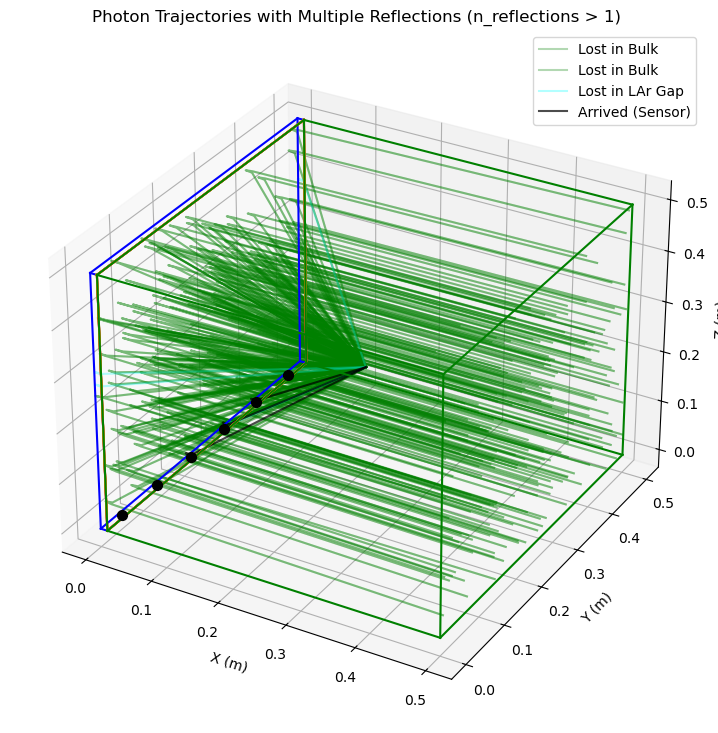

In [ ]:
# Plot only trajectories with multiple reflections (n_reflections > 1)

plt.figure(figsize=(12, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

def plot_trajectories(df_subset, color, label, alpha=0.3, max_lines=200):
  for i, traj_str in enumerate(df_subset['trajectory']):
    if i >= max_lines:
      break
    points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
    ax.plot(points[:,0], points[:,1], points[:,2], color=color, alpha=alpha, label=label if i == 0 else None)

df_multi_refl = df[df['n_reflections'] > 0]
plot_trajectories(df_multi_refl, 'green', 'Lost in Bulk')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_bulk'], 'green', 'Lost in Bulk')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_dm'], 'orange', 'Lost in DM')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_wls'], 'red', 'Lost in WLS')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_lar_gap'], 'cyan', 'Lost in LAr Gap')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_lc'], 'blue', 'Lost in LC')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'arrived'], 'k', 'Arrived (Sensor)', alpha=0.7)

draw_box(lc_region_vertices, "blue")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
  ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title('Photon Trajectories with Multiple Reflections (n_reflections > 1)')
ax.legend()
plt.show()


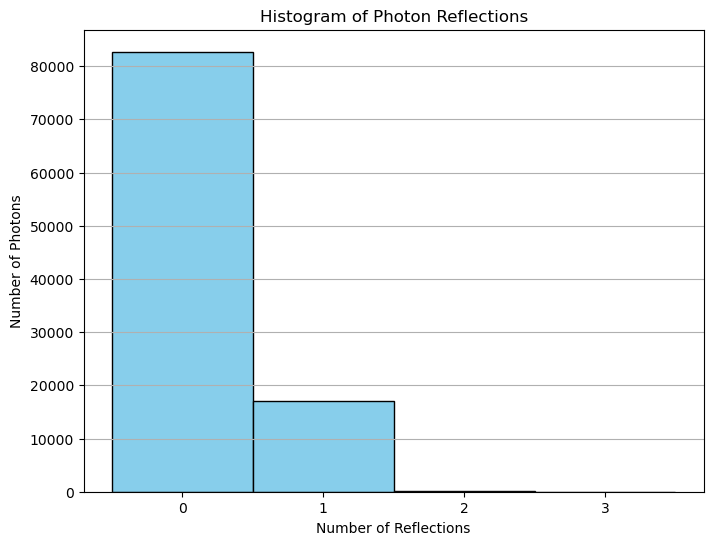

In [ ]:
# make a histogram of  number of reflections
plt.figure(figsize=(8, 6))
plt.hist(df['n_reflections'], bins=range(0, df['n_reflections'].max()+2), align='left', color='skyblue', edgecolor='black')
plt.xlabel('Number of Reflections')
plt.ylabel('Number of Photons')
plt.title('Histogram of Photon Reflections')
plt.xticks(range(0, df['n_reflections'].max()+1))
plt.grid(axis='y')
plt.show()

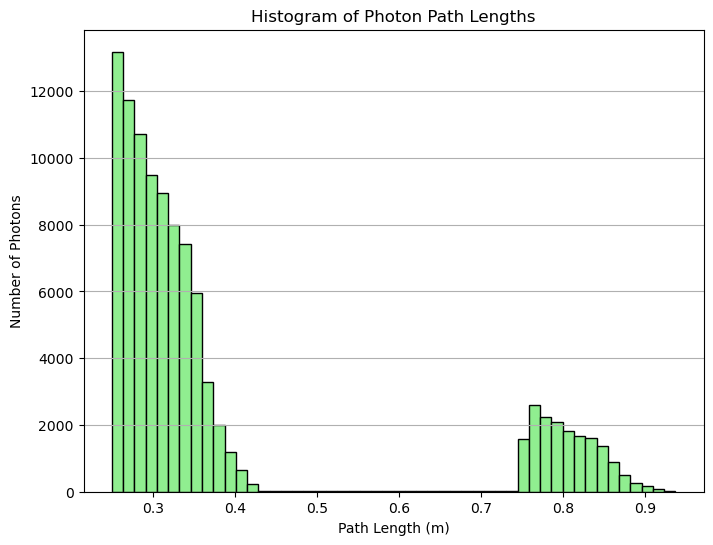

In [ ]:
# make a histgoram of path lengths
plt.figure(figsize=(8, 6))
plt.hist(df['path_length'], bins=50, color='lightgreen', edgecolor='black')
plt.xlabel('Path Length (m)')
plt.ylabel('Number of Photons')
plt.title('Histogram of Photon Path Lengths')
plt.grid(axis='y')
plt.show()

In [ ]:
#print(df["event_type"].value_counts().head(30))

#print(df[df["n_reflections"] > 0]["event_type"].value_counts())

print(pd.crosstab(df["event_type"], df["n_reflections"]))


n_reflections       0      1    2  3
event_type                          
arrived            48      3    0  0
lost_absorb_lc    323      2    0  0
lost_bulk       82345  17128  145  1
lost_lar_gap        1      4    0  0
